# QAOA FOR FINANCE

### IMPORT

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.optimize import minimize
from itertools import product 
from functools import reduce

### GLOBAL PARAMS

In [35]:
np.random.seed(42)

### DATA

In [36]:
anti = pd.read_parquet('../data/anti.parquet')
mag7 = pd.read_parquet('../data/mag7.parquet')
quantum = pd.read_parquet('../data/quantum.parquet')
quantum_big = pd.read_parquet('../data/quantum_big.parquet')

dfs = [anti, mag7, quantum, quantum_big]
df = reduce(lambda left, right: pd.merge(left, right, on='Date'), dfs)
print(df.head(2))

Ticker            XOM        DAL        NEM         JPM        AAPL  \
Date                                                                  
2022-08-01  83.171013  31.269651  40.333305  104.126549  158.477478   
2022-08-02  82.810097  30.871868  40.243565  102.503693  157.005661   

Ticker            MSFT     GOOGL_x        AMZN  IONQ  RGTI  QBTS  QUBT  \
Date                                                                     
2022-08-01  269.566498  113.918465  135.389999  5.25  4.11  8.77  3.29   
2022-08-02  266.473389  114.186249  134.160004  5.51  4.06  8.65  3.33   

Ticker             IBM         HON     GOOGL_y       NVDA  
Date                                                       
2022-08-01  114.002602  167.142120  113.918457  18.411377  
2022-08-02  113.804024  164.643555  114.186256  18.496241  


### VISUALS

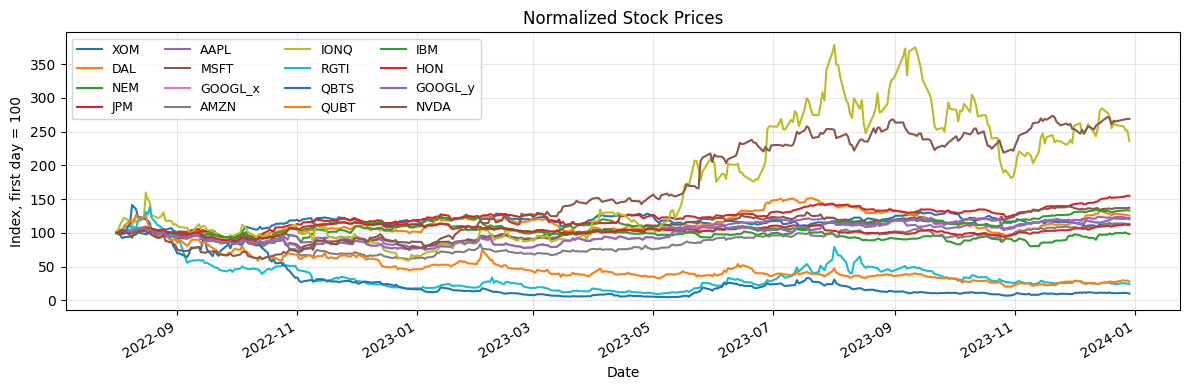

In [37]:
cols = ["XOM", "DAL", "NEM", "JPM", "AAPL", "MSFT", "AMZN", "NVDA"]

norm = df / df.iloc[0] * 100

norm.plot(figsize=(12, 4), linewidth=1.5)

plt.title("Normalized Stock Prices")
plt.xlabel("Date")
plt.ylabel("Index, first day = 100")
plt.grid(True, alpha=0.3)
plt.legend(ncol=4, fontsize=9)
plt.tight_layout()
plt.show()